# 01 - EDA Correlation

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) tập trung vào độ tương quan giữa các đặc trưng của bộ dữ liệu Abalone và biến mục tiêu `Rings` (tuổi của con trai). Bộ dữ liệu bao gồm các đặc trưng như `Sex`, `Length`, `Diameter`, `Height`, `WholeWeight`, `ShuckedWeight`, `VisceraWeight`, `ShellWeight` và `Rings`.

### Thực hiện:
- Nạp và chuẩn bị dữ liệu từ file CSV.
- Tính toán và trực quan hóa ma trận tương quan giữa các biến số.
- Xác định các đặc trưng có tương quan mạnh nhất với `Rings` (ví dụ: `ShellWeight`, `Diameter`, `Height`, `Length`).
- Sử dụng các biểu đồ như heatmap, bar plot, scatter plot, pair plot và violin plot để phân tích mối quan hệ, bao gồm phân loại theo `Sex`.

### Kết quả chính:
- `ShellWeight` có tương quan cao nhất với `Rings` (0.63), cho thấy đây là chỉ báo tốt nhất cho tuổi.
- Các phân tích trực quan giúp hiểu rõ mối quan hệ tuyến tính và phân phối dữ liệu theo giới tính.
- Kết quả này có thể được sử dụng để lựa chọn đặc trưng cho mô hình dự đoán tuổi abalone.

### Chuẩn bị thư viện

In [ ]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if 'notebooks' in str(PROJECT_ROOT):
    while PROJECT_ROOT.name != 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Dung helper load du lieu tu src/data/load_data.py
from src.data.load_data import ABALONE_COLUMNS, load_abalone_data

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Nạp dữ liệu

In [ ]:
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'abalone.csv'

# Goi ham load_abalone_data() trong src/data/load_data.py
columns = ABALONE_COLUMNS.copy()
df = load_abalone_data(DATA_PATH, columns=columns)
display(df.head())

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Phân tích độ tương quan

### 2.1 Ma trận tương quan

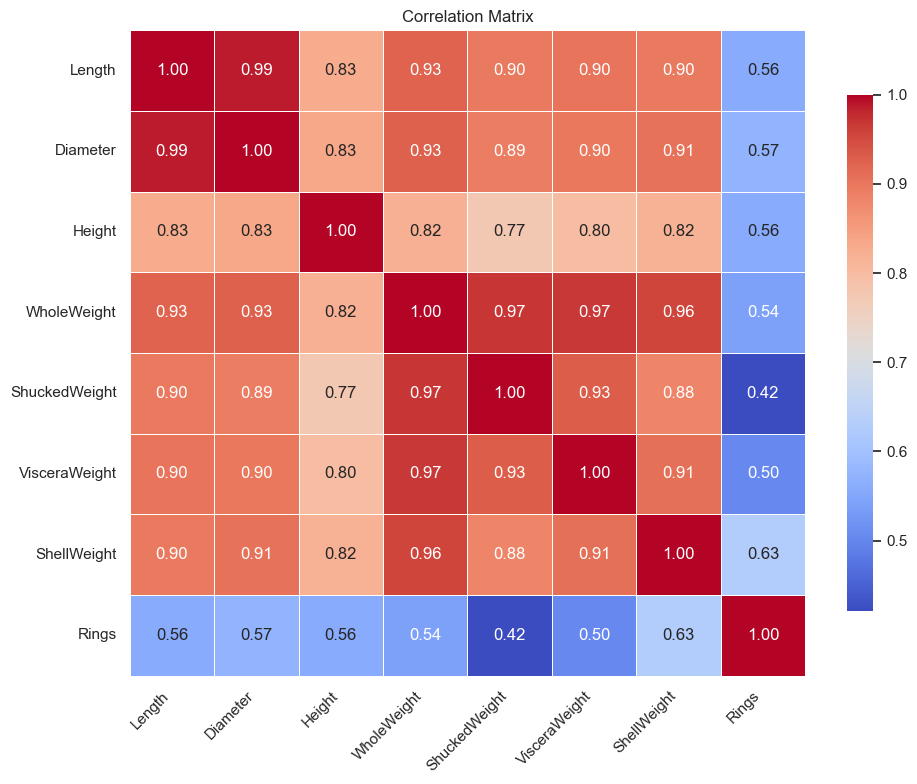

,corr_with_rings
ShellWeight,0.627574
Diameter,0.574660
Height,0.557467
Length,0.556720
WholeWeight,0.540390
VisceraWeight,0.503819
ShuckedWeight,0.420884


In [ ]:
# Tính ma trận tương quan
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# # Lưu biểu đồ
# plt.savefig(os.path.join(report_path, "correlation_matrix.png"), dpi=200, bbox_inches="tight")

plt.show()

# Lấy tương quan với biến mục tiêu 'Rings'
corr_with_target = corr['Rings'].drop('Rings').sort_values(ascending=False).to_frame('corr_with_rings')
display(corr_with_target)

- Biến `Rings` có tương quan dương với tất cả các đặc trưng số (Length, Diameter, Height, WholeWeight, …).  
- Mối quan hệ mạnh nhất: `ShellWeight` (0.6276), tiếp theo `Diameter` (0.5747), `Height` (0.5575), `Length` (0.5567).  
- Các trọng lượng khác (`WholeWeight`, `VisceraWeight`, `ShuckedWeight`) tương quan vừa phải với `Rings` (0.42 - 0.54).  
- Nghĩa là con trai tuổi (Rings) lớn hơn có xu hướng kích thước và khối lượng tăng theo, đặc biệt vỏ (`ShellWeight`) là chỉ báo tốt nhất.  
- Nên ưu tiên dùng `ShellWeight`, `Diameter`, `Height`, `Length` khi xây mô hình dự đoán tuổi.

### 2.2 Correlation Bar Plot

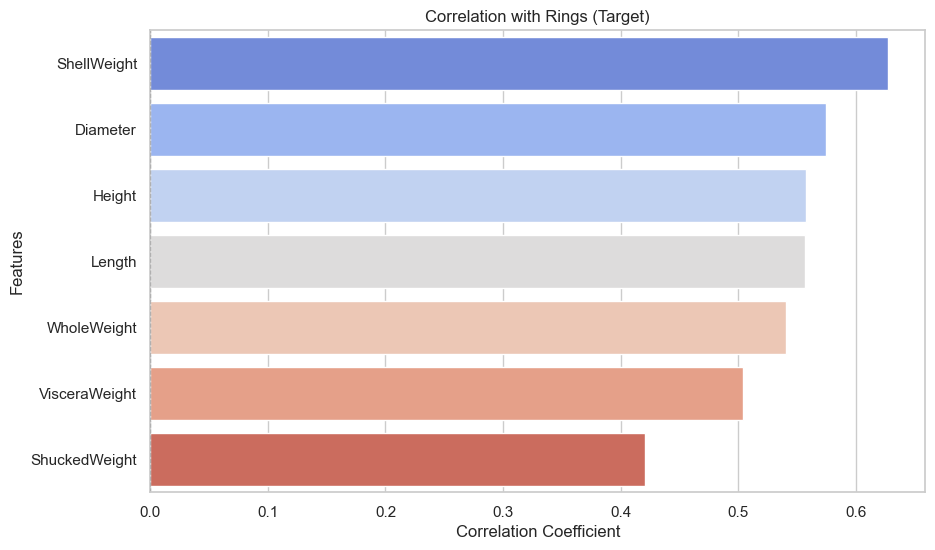

In [ ]:
# Bar plot cho tương quan với Rings
corr_with_target = corr['Rings'].drop('Rings').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title("Correlation with Rings (Target)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)  # Đường trung hòa
plt.show()

- Biểu đồ thanh cho thấy mức độ tương quan của từng biến với `Rings`.  
- `ShellWeight` có tương quan cao nhất (0.63), tiếp theo là `Diameter` (0.57), `Height` (0.56), `Length` (0.56).  
- Các biến này nên được ưu tiên trong feature selection cho mô hình dự đoán tuổi.

### 2.3 Biểu đồ Scatterplot

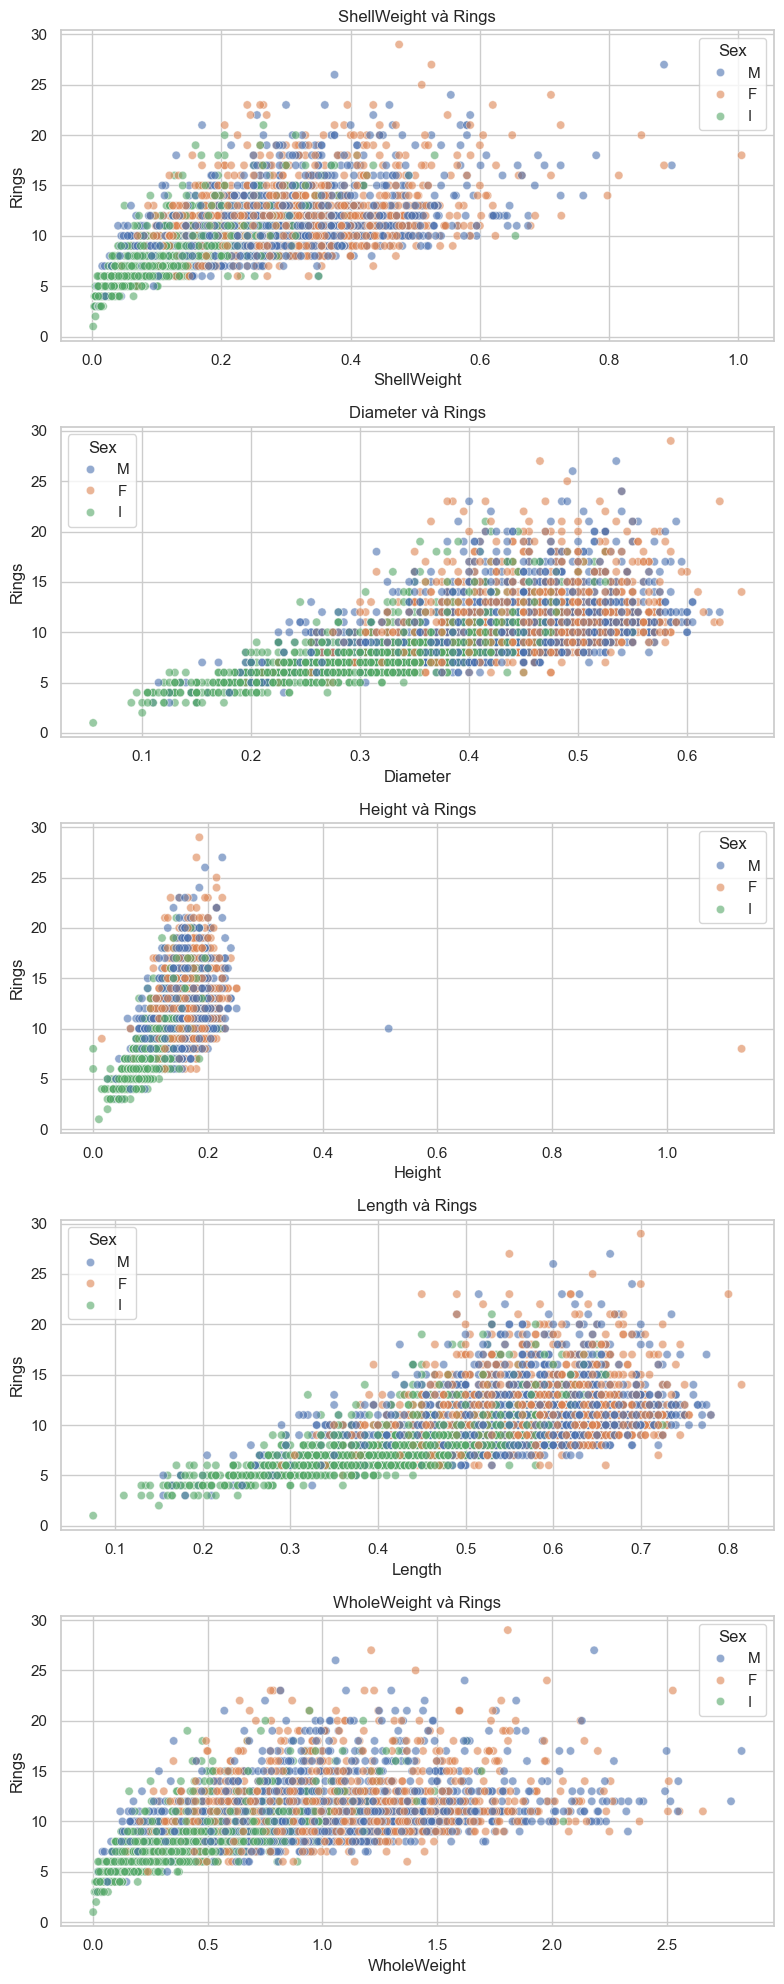

In [ ]:
key_features = corr['Rings'].drop('Rings').abs().sort_values(ascending=False).head(5).index.tolist() # Lấy 5 biến có tương quan cao nhất với 'Rings'

# Vẽ scatter plot cho các biến quan trọng với 'Rings'
fig, axes = plt.subplots(len(key_features), 1, figsize=(8, 4 * len(key_features)))
for ax, col in zip(axes, key_features):
    sns.scatterplot(data=df, x=col, y='Rings', hue='Sex', alpha=0.6, ax=ax)
    ax.set_title(f'{col} và Rings')
plt.tight_layout()
plt.show()

### 2.4 Scatter Plot với Regression Line

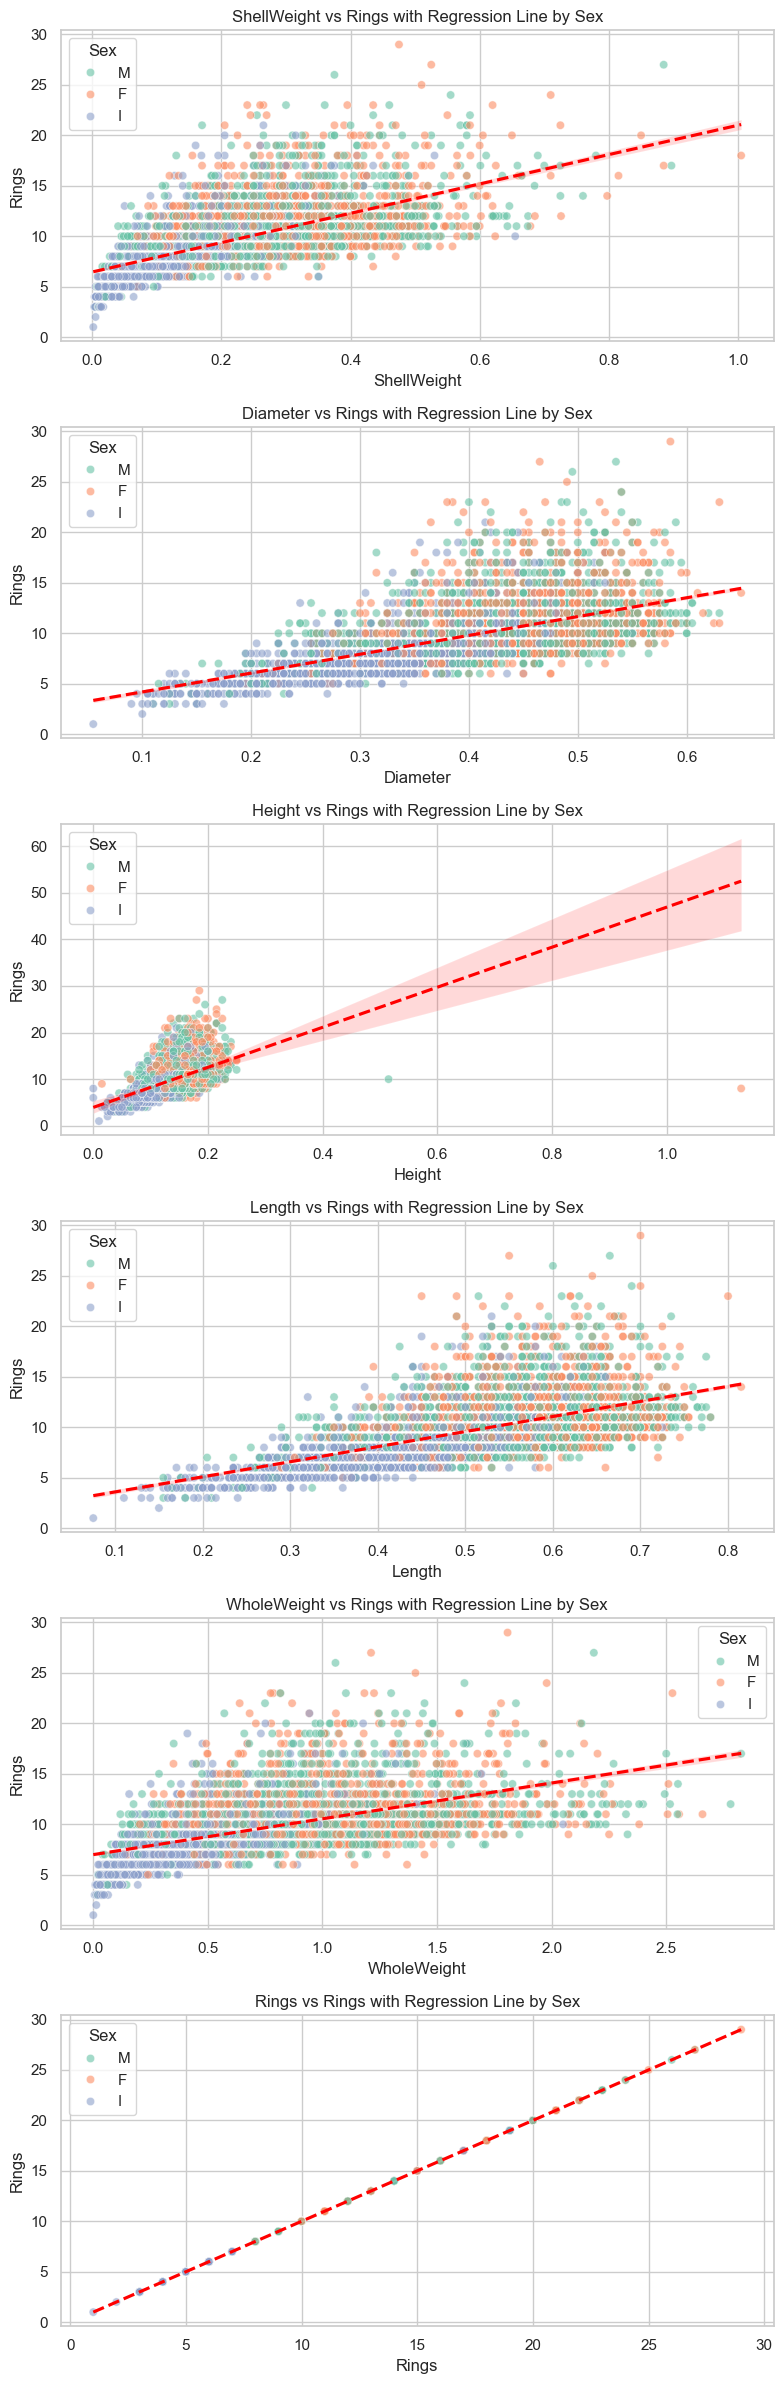

In [ ]:
# Scatter plot với regression line theo Sex
fig, axes = plt.subplots(len(key_features), 1, figsize=(8, 4 * len(key_features)))
for ax, col in zip(axes, key_features):
    sns.scatterplot(data=df, x=col, y='Rings', hue='Sex', ax=ax, alpha=0.6, palette='Set2')
    sns.regplot(data=df, x=col, y='Rings', ax=ax, scatter=False, line_kws={'color': 'red', 'linestyle': '--'})
    ax.set_title(f'{col} vs Rings with Regression Line by Sex')
plt.tight_layout()
plt.show()

### 2.5 Pair Plot

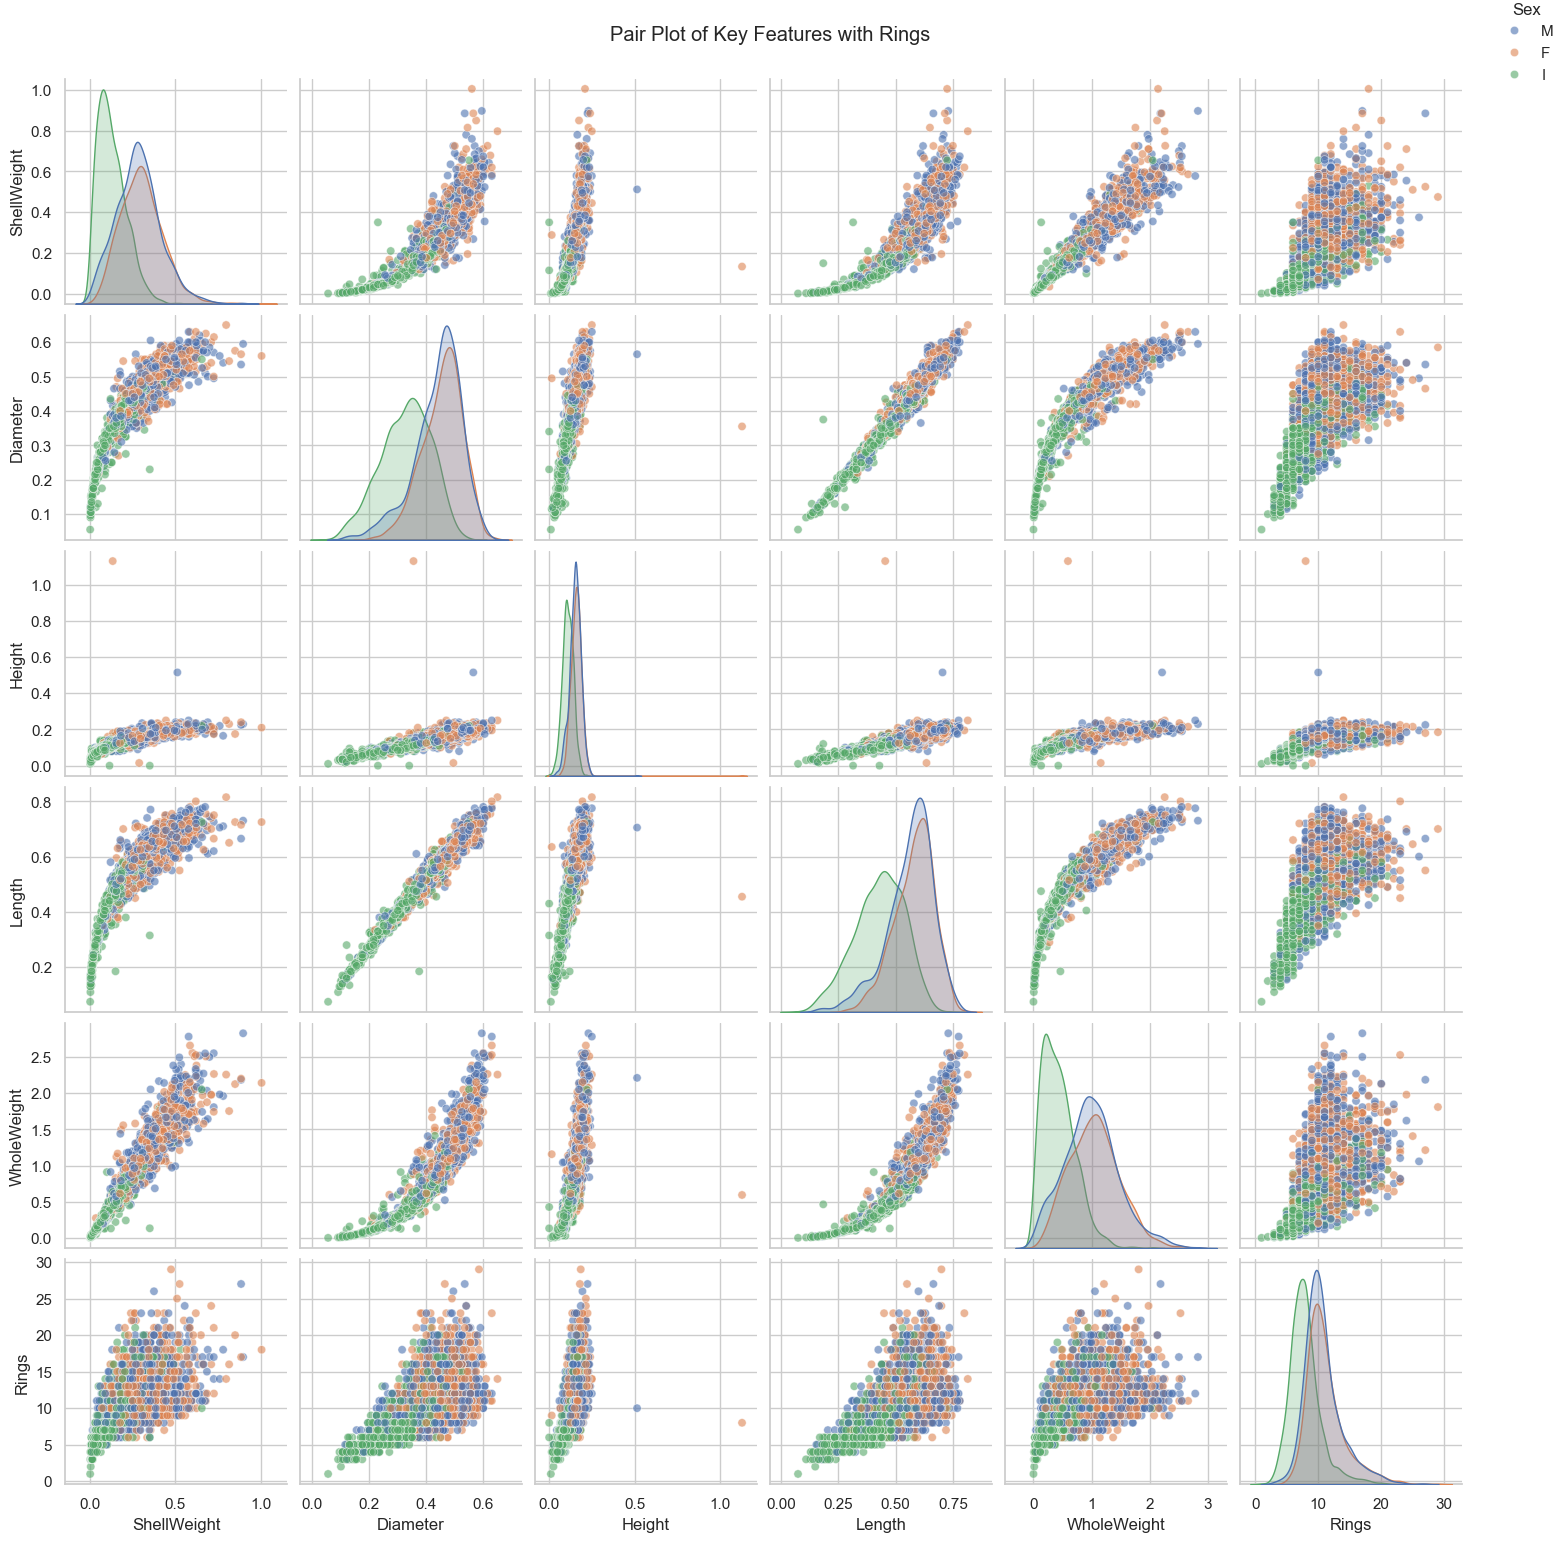

In [ ]:
# Pair plot cho các biến quan trọng
key_features = corr['Rings'].drop('Rings').abs().sort_values(ascending=False).head(5).index.tolist()
key_features.append('Rings')  # Thêm biến mục tiêu
g = sns.pairplot(df, vars=key_features, hue='Sex', diag_kind='kde', plot_kws={'alpha': 0.6})
g._legend.set_bbox_to_anchor((1, 1)) # Di chuyển legend lên góc trên bên phải
plt.suptitle("Pair Plot of Key Features with Rings", y=1.02)
plt.show()

### 2.6 Violin Plot theo Sex

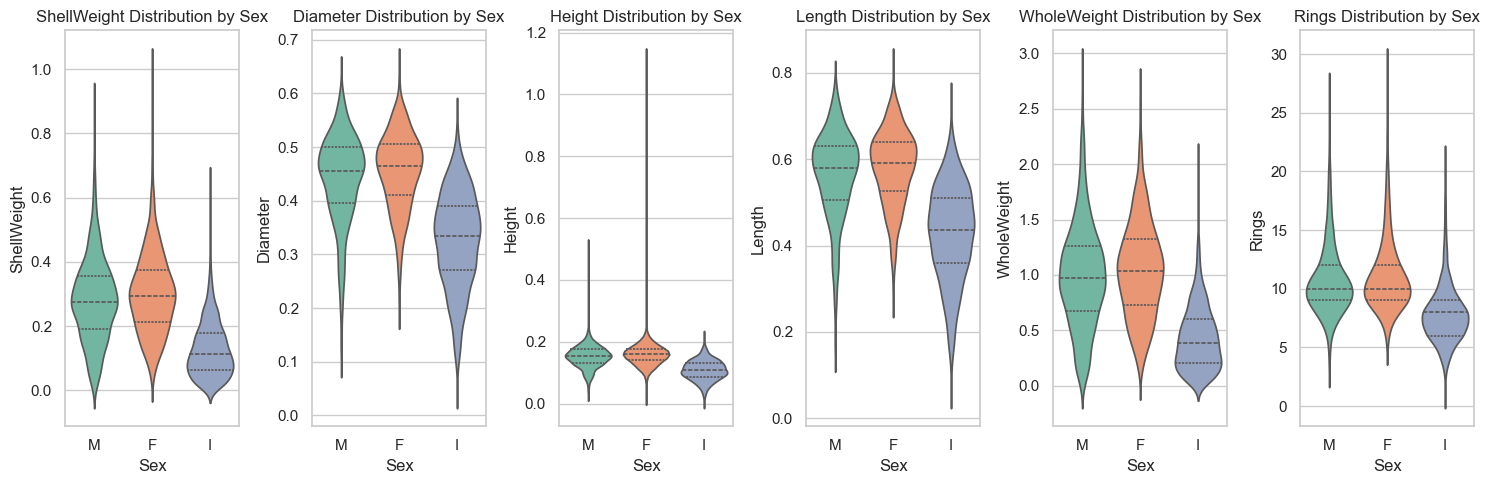

In [ ]:
# Violin plot cho biến quan trọng theo Sex
fig, axes = plt.subplots(1, len(key_features), figsize=(15, 5))
for ax, col in zip(axes, key_features):
    sns.violinplot(data=df, x='Sex', y=col, ax=ax, inner='quartile', palette='Set2')
    ax.set_title(f'{col} Distribution by Sex')
plt.tight_layout()
plt.show()